<a href="https://colab.research.google.com/github/jgmsantos/minicurso_queimadas_2026/blob/main/Aula_1_ex03_focos_anual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

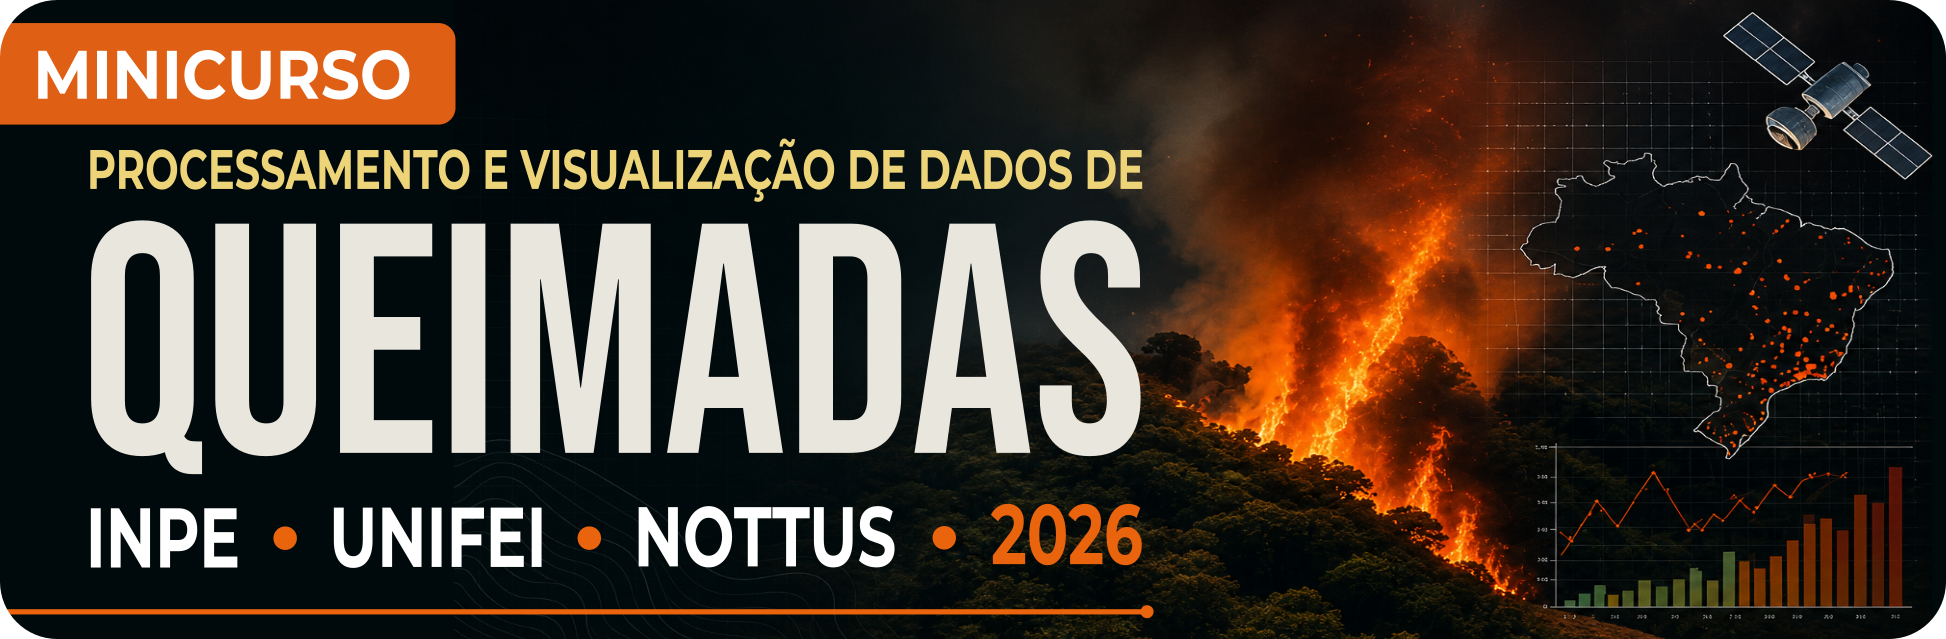

🎯**Objetivo:**


**Processar e visualizar** arquivos anuais e mensais de focos de queimadas do satélite **AQUA_M-T** sobre o Brasil utilizando dados gratuitos do Programa Queimadas do INPE. Serão utilizados dados desde 2003 até julho de 2026.


---


🧑**Palestrante/Tutor**

Dr. Guilherme Martins - Nottus Meteorologia

✉ guilherme.martins@nottus.com.br | jgmsantos@gmail.com

🌎 https://github.com/jgmsantos

🌎 https://guilherme.readthedocs.io/en/latest/


---


✅**Aulas ministradas**

- Aula_1_ex01: https://colab.research.google.com/drive/1mznslPhwRJlc75Vc2oJM-JR0g3M0K9b5?usp=sharing
- Aula_1_ex02: https://colab.research.google.com/drive/1Xehetg_R3WMwq1E889q7XgKbLAceur6s?usp=sharing

---

📚**Material de apoio sobre Python**

https://guilherme.readthedocs.io/en/latest/pages/tutoriais/python.html

---

🎲**Dados utilizados no formato csv**
- Focos anuais:
  - https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref
- Focos mensais de 2026:
  - https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil

---

✅**Atividades a serem desenvolvidas**
1. Aprender a importar bibliotecas
1. Montar o drive para ler/salvar arquivos
1. Acessar os dados anuais e mensais de focos
1. Explorar os dados
1. Concatenar os arquivos
1. Processar e visualizar por estado
   - Filtrar datas
   - Filtrar área de interesse (município, estado ou bioma)
   - Calcular algumas métricas
1. Processar e visualizar o dado mensal
   -. Calcular acumulado mensal
   -. Calcular média mensal
   -. Heatmap
1. Processar e visualizar o dado anual
   - Calcular o acumulado anual
   - Calcular porcentagem em relação à média
   - Calcular a variação percentual do ano corrente em relação ao ano anterior

---

❗**Importante**

- Necessário possuir uma conta do Gmail.
- Salvar este código no seu Google Drive. Basta clicar em **Arquivo** (canto superior esquerdo) e depois em **Salvar uma cópia no drive** e fazer o login numa conta Google.
- Sugestão: Criar uma pasta no seu Google Drive com um nome quaquer. Dentro dela, criar duas novas pastas, **figuras** e **shapefile**. Estes arquivos são usados no exercício 1.
  - Na pasta **shapefile** colocar os arquivos abaixo:
    - a__031_001_americaDoSul.cst
    - a__031_001_americaDoSul.dbf
    - a__031_001_americaDoSul.prj
    - a__031_001_americaDoSul.shp
    - a__031_001_americaDoSul.shx
    - BR_UF_2022.cpg
    - BR_UF_2022.dbf
    - BR_UF_2022.prj
    - BR_UF_2022.shp
    - BR_UF_2022.shx

---

## Importação de bibliotecas

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Para visualização de dados baseada no Matplotlib.
import os # Para criar diretórios para salvar as figuras.
import numpy as np # Usado para operações matemáticas.

# Montar o drive para ler/salvar arquivos que estão no seu Google Drive.
# Não precisa alterar nada, é assim mesmo.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Local para salvar as figuras.
# ALTERAR AQUI APONTANDO PARA A PASTA "figuras".
diretorio_figuras = "/content/drive/MyDrive/cursos/queimadas_2026/scripts/figuras"

# Cria o diretório acima caso ele não exista.
os.makedirs(diretorio_figuras, exist_ok=True)

## Processamento dos dados anuais

Os dados anuais correspondem aos anos entre 2003 e 2025.

In [5]:
# Tempo de execução: 00:00:54.

# Colunas dos arquivos anuais: 9 colunas.
# id_bdq,foco_id,lat,lon,data_pas,pais,estado,municipio,bioma

# https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref

# nome do arquivo: 	focos_br_ref_2003.zip

# Dados desde: 2003 até 2025.

# URL dos arquivos anuais do satélite AQUA_M-T.
url_anual = 'https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref'

lista_anual = [] # Lista vazia.

# Serão utilizadas apenas 6 colunas.
colunas_interesse = [
    "lat", "lon", "data_pas", "estado", "municipio", "bioma"
  ]

# Percorre todos os anos disponíveis.
# Ao usar range, sempre colocar um ano adicional.
# Como será feito até 2025, então, o último ano é 2026.
# Se colocar 2025, será feito até 2024.
for ano in range(2003, 2026):

  print(f"Processando o ano: {ano}")

  # Nome do arquivo que está na URL acima.
  nome_arquivo = f"focos_br_ref_{ano}.zip"

  # URL com o nome do arquivo que será processado.
  url_com_arquivo = f"{url_anual}/{nome_arquivo}"

  try:
    # Leitura de cada arquivo selecionando apenas as colunas de interesse e
    # definindo a coluna "data_pas" como Datetime (parse_dates).
    df_tmp = pd.read_csv(
        url_com_arquivo,
        compression='zip', # Isso porque o arquivo está zipado.
        usecols=colunas_interesse,
        parse_dates=["data_pas"]
    )

    # Se df_tmp está vazio (empty).
    if df_tmp.empty:
      print(f"O DataFrame está vazio para o ano: {ano}")
      continue

    # Lista de DataFrames.
    lista_anual.append(df_tmp)

  except Exception as e:

    print(f"Erro ao ler {nome_arquivo}: {e}")

# Concatena a lista com todos os DataFrames em um único DataFrame.
# https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_anual = pd.concat(lista_anual, ignore_index=True)

Processando o ano: 2003
Processando o ano: 2004
Processando o ano: 2005
Processando o ano: 2006
Processando o ano: 2007
Processando o ano: 2008
Processando o ano: 2009
Processando o ano: 2010
Processando o ano: 2011
Processando o ano: 2012
Processando o ano: 2013
Processando o ano: 2014
Processando o ano: 2015
Processando o ano: 2016
Processando o ano: 2017
Processando o ano: 2018
Processando o ano: 2019
Processando o ano: 2020
Processando o ano: 2021
Processando o ano: 2022
Processando o ano: 2023
Processando o ano: 2024
Processando o ano: 2025


In [7]:
# Visualizando o DataFrame.
df_anual

,lat,lon,data_pas,estado,municipio,bioma
0,-18.51800,-55.02800,2003-05-15 17:05:00,MATO GROSSO DO SUL,RIO VERDE DE MATO GROSSO,Cerrado
1,-17.54200,-48.81500,2003-05-15 17:05:00,GOIÁS,PIRACANJUBA,Cerrado
2,-17.61200,-47.16000,2003-05-15 17:05:00,MINAS GERAIS,GUARDA-MOR,Cerrado
3,-18.38600,-51.91900,2003-05-15 17:05:00,GOIÁS,SERRANÓPOLIS,Cerrado
4,-17.87700,-49.09800,2003-05-15 17:05:00,GOIÁS,MORRINHOS,Cerrado
...,...,...,...,...,...,...
5244361,-1.22162,-53.75204,2025-12-31 18:34:00,PARÁ,PRAINHA,Amazônia
5244362,-3.33657,-50.22624,2025-12-31 18:34:00,PARÁ,PACAJÁ,Amazônia
5244363,-2.46039,-49.00666,2025-12-31 18:34:00,PARÁ,MOJU,Amazônia
5244364,-2.32217,-45.82032,2025-12-31 18:34:00,MARANHÃO,PRESIDENTE MÉDICI,Amazônia


In [6]:
# Verificação do tipo de dado.
df_anual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5244366 entries, 0 to 5244365
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   lat        float64       
 1   lon        float64       
 2   data_pas   datetime64[ns]
 3   estado     object        
 4   municipio  object        
 5   bioma      object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 240.1+ MB


In [8]:
# Ordenar as datas cronologicamente.
df_anual = df_anual.sort_values("data_pas")

In [9]:
# Visualizando o DataFrame.
df_anual

,lat,lon,data_pas,estado,municipio,bioma
849,-14.82900,-40.13300,2003-01-01 16:04:00,BAHIA,NOVA CANAÃ,Mata Atlântica
851,-15.62100,-41.66500,2003-01-01 16:04:00,MINAS GERAIS,BERIZAL,Mata Atlântica
850,-15.27600,-41.51400,2003-01-01 16:04:00,BAHIA,TREMEDAL,Mata Atlântica
847,-10.11100,-36.50500,2003-01-01 16:05:00,ALAGOAS,IGREJA NOVA,Caatinga
846,-11.88600,-37.81500,2003-01-01 16:05:00,BAHIA,ESPLANADA,Mata Atlântica
...,...,...,...,...,...,...
5244318,0.69087,-60.36650,2025-12-31 18:36:00,RORAIMA,RORAINÓPOLIS,Amazônia
5244343,-0.09348,-51.28310,2025-12-31 18:36:00,AMAPÁ,MAZAGÃO,Amazônia
5244330,0.68670,-60.35904,2025-12-31 18:36:00,RORAIMA,RORAINÓPOLIS,Amazônia
5244334,-0.15601,-51.33309,2025-12-31 18:36:00,AMAPÁ,MAZAGÃO,Amazônia


## Processamento dos dados mensais para o ano de 2026 para o satélite AQUA_M-T

Nestes arquivos estão todos os satélites.

In [10]:
# Tempo de execução: 00:00:54.

# Colunas dos arquivos anuais: 16 colunas.
# id,lat,lon,data_hora_gmt,satelite,municipio,estado,pais,municipio_id,estado_id,pais_id,numero_dias_sem_chuva,precipitacao,risco_fogo,bioma,frp

# https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil

# nome do arquivo: 	focos_mensal_br_202601.csv

# Dados desde: 202301-atual.

# URL dos arquivos mensais com todos os satélites somente para o Brasil.
url_mensal = 'https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil'

lista_mensal = [] # Lista vazia.

# Serão usadas 7 colunas.
colunas_interesse = [
    "lat" ,"lon" ,"data_hora_gmt" ,"satelite" ,"municipio" ,"estado" ,"bioma"
  ]

# Loop ao longo dos meses.
for mes in range(1, 8):

  print(f"Processando o mes {mes:02d} de 2026")

  # Nome do arquivo que está na URL.
  nome_arquivo = f"focos_mensal_br_2026{mes:02d}.csv"

  # URL com o nome do arquivo que será processado.
  url_com_arquivo = f"{url_mensal}/{nome_arquivo}"

  try:
    # Leitura de cada arquivo selecionando apenas as colunas de interesse e
    # definindo a coluna "data_hora_gmt" como Datetime.
    df_tmp = pd.read_csv(
        url_com_arquivo,
        usecols=colunas_interesse,
        parse_dates=["data_hora_gmt"]
    )

    # Se df_tmp está vazio (empty).
    if df_tmp.empty:
      print(f"O DataFrame está vazio para o mes: {mes:02d}")
      continue

    # Lista de DataFrames. Ou seja, empilha os DataFrames.
    lista_mensal.append(df_tmp)

  except Exception as e:
    print(f"Erro ao ler {nome_arquivo}: {e}")

# Concatena todos os DataFrames em um único DataFrame.
# https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_mensal = pd.concat(lista_mensal)

Processando o mes 01 de 2026
Processando o mes 02 de 2026
Processando o mes 03 de 2026
Processando o mes 04 de 2026
Processando o mes 05 de 2026
Processando o mes 06 de 2026
Processando o mes 07 de 2026


In [12]:
# Visualização do DataFrame.
df_mensal

,lat,lon,data_hora_gmt,satelite,municipio,estado,bioma
0,-9.563100,-44.603000,2026-01-01 00:00:00,GOES-19,REDENÇÃO DO GURGUÉIA,PIAUÍ,Cerrado
1,-9.582100,-44.600700,2026-01-01 00:00:00,GOES-19,REDENÇÃO DO GURGUÉIA,PIAUÍ,Cerrado
2,-22.891701,-43.709599,2026-01-01 00:05:00,METOP-B,RIO DE JANEIRO,RIO DE JANEIRO,Mata Atlântica
3,-1.368700,-46.052200,2026-01-01 00:05:00,METOP-B,CARUTAPERA,MARANHÃO,Amazônia
4,-3.861600,-54.214298,2026-01-01 00:05:00,METOP-B,PLACAS,PARÁ,Amazônia
...,...,...,...,...,...,...,...
96448,-12.150300,-48.262800,2026-07-20 23:50:00,GOES-19,PEIXE,TOCANTINS,Cerrado
96449,-10.523700,-50.299300,2026-07-20 23:50:00,GOES-19,PIUM,TOCANTINS,Cerrado
96450,-10.523400,-50.320700,2026-07-20 23:50:00,GOES-19,PIUM,TOCANTINS,Cerrado
96451,-10.862600,-50.413000,2026-07-20 23:50:00,GOES-19,LAGOA DA CONFUSÃO,TOCANTINS,Cerrado


In [11]:
# Verificação do tipo de dado.
df_mensal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 513036 entries, 0 to 96452
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   lat            513036 non-null  float64       
 1   lon            513036 non-null  float64       
 2   data_hora_gmt  513036 non-null  datetime64[ns]
 3   satelite       513036 non-null  object        
 4   municipio      513036 non-null  object        
 5   estado         513036 non-null  object        
 6   bioma          513030 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 31.3+ MB


In [13]:
# Selecionar o satélite AQUA_M-T.
df_mensal = df_mensal[df_mensal["satelite"] == "AQUA_M-T"]

# Visualização do DataFrame.
df_mensal

,lat,lon,data_hora_gmt,satelite,municipio,estado,bioma
2335,-15.56401,-41.23895,2026-01-01 17:32:00,AQUA_M-T,ENCRUZILHADA,BAHIA,Mata Atlântica
2336,-15.55695,-39.17970,2026-01-01 17:32:00,AQUA_M-T,SANTA LUZIA,BAHIA,Mata Atlântica
2337,-16.13573,-42.28960,2026-01-01 17:32:00,AQUA_M-T,SALINAS,MINAS GERAIS,Mata Atlântica
2338,-12.67144,-41.56548,2026-01-01 17:32:00,AQUA_M-T,PALMEIRAS,BAHIA,Caatinga
2339,-17.51794,-39.52960,2026-01-01 17:32:00,AQUA_M-T,ALCOBAÇA,BAHIA,Mata Atlântica
...,...,...,...,...,...,...,...
95882,-7.77881,-73.08250,2026-07-20 20:19:00,AQUA_M-T,RODRIGUES ALVES,ACRE,Amazônia
95883,-9.10678,-71.26778,2026-07-20 20:19:00,AQUA_M-T,FEIJÓ,ACRE,Amazônia
95884,-8.27815,-70.89651,2026-07-20 20:19:00,AQUA_M-T,TARAUACÁ,ACRE,Amazônia
95885,-9.65152,-67.06826,2026-07-20 20:19:00,AQUA_M-T,LÁBREA,AMAZONAS,Amazônia


In [14]:
# Remove a coluna satelite porque já foi selecionado o satélite AQUA_M-T.
df_mensal = df_mensal.drop(columns="satelite")

In [15]:
# Ordenar as datas cronologicamente.
df_mensal = df_mensal.sort_values("data_hora_gmt")

df_mensal

,lat,lon,data_hora_gmt,municipio,estado,bioma
2335,-15.56401,-41.23895,2026-01-01 17:32:00,ENCRUZILHADA,BAHIA,Mata Atlântica
2348,-15.80683,-39.34556,2026-01-01 17:32:00,MASCOTE,BAHIA,Mata Atlântica
2347,-12.67405,-41.58709,2026-01-01 17:32:00,PALMEIRAS,BAHIA,Caatinga
2346,-17.52479,-39.53572,2026-01-01 17:32:00,ALCOBAÇA,BAHIA,Mata Atlântica
2344,-15.55698,-39.16919,2026-01-01 17:32:00,SANTA LUZIA,BAHIA,Mata Atlântica
...,...,...,...,...,...,...
95881,-8.94582,-71.55865,2026-07-20 20:19:00,JORDÃO,ACRE,Amazônia
95882,-7.77881,-73.08250,2026-07-20 20:19:00,RODRIGUES ALVES,ACRE,Amazônia
95883,-9.10678,-71.26778,2026-07-20 20:19:00,FEIJÓ,ACRE,Amazônia
95884,-8.27815,-70.89651,2026-07-20 20:19:00,TARAUACÁ,ACRE,Amazônia


In [16]:
# Visualizar o nome das colunas de df_anual.
df_anual.columns

Index(['lat', 'lon', 'data_pas', 'estado', 'municipio', 'bioma'], dtype='object')

In [17]:
# Visualizar o nome das colunas de df_mensal.
df_mensal.columns

Index(['lat', 'lon', 'data_hora_gmt', 'municipio', 'estado', 'bioma'], dtype='object')

## Concatenar os DataFrames anual e mensal

Uma vez gerados o df_anual e o df_mensal, a ideia é concatená-los em um único DataFrame (2003 até 2026). Para isso, é necessário que as colunas obrigatoriamente tenham o mesmo nome, a ordem delas não influencia.

In [18]:
# Cria uma cópia dos DataFrames para evitar reprocessamento dos dados.
df_anual_copia = df_anual.copy()
df_mensal_copia = df_mensal.copy()

# Reordenar as colunas do df_anual para a mesma ordem do df_mensal.
df_anual_copia = df_anual_copia[["lat", "lon", "data_pas", "municipio", "estado", "bioma"]]

# Visualização do DataFrame.
df_anual_copia

,lat,lon,data_pas,municipio,estado,bioma
849,-14.82900,-40.13300,2003-01-01 16:04:00,NOVA CANAÃ,BAHIA,Mata Atlântica
851,-15.62100,-41.66500,2003-01-01 16:04:00,BERIZAL,MINAS GERAIS,Mata Atlântica
850,-15.27600,-41.51400,2003-01-01 16:04:00,TREMEDAL,BAHIA,Mata Atlântica
847,-10.11100,-36.50500,2003-01-01 16:05:00,IGREJA NOVA,ALAGOAS,Caatinga
846,-11.88600,-37.81500,2003-01-01 16:05:00,ESPLANADA,BAHIA,Mata Atlântica
...,...,...,...,...,...,...
5244318,0.69087,-60.36650,2025-12-31 18:36:00,RORAINÓPOLIS,RORAIMA,Amazônia
5244343,-0.09348,-51.28310,2025-12-31 18:36:00,MAZAGÃO,AMAPÁ,Amazônia
5244330,0.68670,-60.35904,2025-12-31 18:36:00,RORAINÓPOLIS,RORAIMA,Amazônia
5244334,-0.15601,-51.33309,2025-12-31 18:36:00,MAZAGÃO,AMAPÁ,Amazônia


In [19]:
# Renomear as colunas do df_anual_copia para os mesmos nomes do df_mensal_copia.
# O único nome diferente é a coluna da hora.
# No anual é "data_pas" e no mensal é "data_hora_gmt".
# Logo, alterar de "data_pas" para "data_hora_gmt".
df_anual_copia = df_anual_copia.rename(columns={"data_pas": "data_hora_gmt"})

# Visualização do DataFrame df_anual_copia.
df_anual_copia

,lat,lon,data_hora_gmt,municipio,estado,bioma
849,-14.82900,-40.13300,2003-01-01 16:04:00,NOVA CANAÃ,BAHIA,Mata Atlântica
851,-15.62100,-41.66500,2003-01-01 16:04:00,BERIZAL,MINAS GERAIS,Mata Atlântica
850,-15.27600,-41.51400,2003-01-01 16:04:00,TREMEDAL,BAHIA,Mata Atlântica
847,-10.11100,-36.50500,2003-01-01 16:05:00,IGREJA NOVA,ALAGOAS,Caatinga
846,-11.88600,-37.81500,2003-01-01 16:05:00,ESPLANADA,BAHIA,Mata Atlântica
...,...,...,...,...,...,...
5244318,0.69087,-60.36650,2025-12-31 18:36:00,RORAINÓPOLIS,RORAIMA,Amazônia
5244343,-0.09348,-51.28310,2025-12-31 18:36:00,MAZAGÃO,AMAPÁ,Amazônia
5244330,0.68670,-60.35904,2025-12-31 18:36:00,RORAINÓPOLIS,RORAIMA,Amazônia
5244334,-0.15601,-51.33309,2025-12-31 18:36:00,MAZAGÃO,AMAPÁ,Amazônia


Apenas checando se os nomes das colunas dos dois DataFrames estão compatíveis.

In [20]:
df_anual_copia.columns

Index(['lat', 'lon', 'data_hora_gmt', 'municipio', 'estado', 'bioma'], dtype='object')

In [21]:
df_mensal_copia.columns

Index(['lat', 'lon', 'data_hora_gmt', 'municipio', 'estado', 'bioma'], dtype='object')

In [22]:
# Concatena os dois DataFrames. O "pd.concat" concatena pelos nomes das colunas
# e não pelas posição delas.
df_final = pd.concat([df_anual_copia, df_mensal_copia], ignore_index=True)

# Renomeia as colunas para nomes definidos pelo usuário.
df_final.columns = ["Lat", "Lon", "Data", "Municipio", "Estado", "Bioma"]

# Visualização do DataFrame.
df_final

,Lat,Lon,Data,Municipio,Estado,Bioma
0,-14.82900,-40.13300,2003-01-01 16:04:00,NOVA CANAÃ,BAHIA,Mata Atlântica
1,-15.62100,-41.66500,2003-01-01 16:04:00,BERIZAL,MINAS GERAIS,Mata Atlântica
2,-15.27600,-41.51400,2003-01-01 16:04:00,TREMEDAL,BAHIA,Mata Atlântica
3,-10.11100,-36.50500,2003-01-01 16:05:00,IGREJA NOVA,ALAGOAS,Caatinga
4,-11.88600,-37.81500,2003-01-01 16:05:00,ESPLANADA,BAHIA,Mata Atlântica
...,...,...,...,...,...,...
5267632,-8.94582,-71.55865,2026-07-20 20:19:00,JORDÃO,ACRE,Amazônia
5267633,-7.77881,-73.08250,2026-07-20 20:19:00,RODRIGUES ALVES,ACRE,Amazônia
5267634,-9.10678,-71.26778,2026-07-20 20:19:00,FEIJÓ,ACRE,Amazônia
5267635,-8.27815,-70.89651,2026-07-20 20:19:00,TARAUACÁ,ACRE,Amazônia


## O que fizemos até aqui?

- Processamento dos arquivos anuais (2003 a 2025) somente do satélite AQUA_M-T.
- Processamento dos arquivos mensais do ano 2026 com todos os satélites.
  - Seleção do satélite AQUA_M-T.
- Concatenação dos dois DataFrames (anual e mensal).
  - Padronização dos nomes e da ordem das colunas do DataFrame anual de acordo com o DataFrame mensal.

## O que queremos fazer?

- realizar filtragem por município, estado ou bioma.
- acumulado em diferentes escalas temporais (diária, mensal, sazonal e anual)
- visualização.

## Processamento e visualização

As análises e as visualizações utilizarão a coluna "Estado" do "df_final" (DataFrame concatenado com todos os anos desde 2003 até julho de 2026).

O que faremos inicialmente?

- reproduzir alguns resultados (tabelas e figuras) gerados pelo Programa Queimadas do INPE.
  - https://data.inpe.br/queimadas/situacao_atual
  - Focos por estado
  - acumulado desde **01/07** até o dia de ontem.
  - acumulado desde **01/01/2026** até o dia de ontem.

### Filtragem de datas

O **ano de 2024** foi escolhido porque houve um **aumento expressivo na quantidade de focos de queimadas**. Para se ter ideia, no Brasil em 2023 foram registrados 29.651 focos contra 44.951 em 2024, isso representa um **aumento de ~52%** de um ano para o outro.

In [26]:
data_inicio = "2024-01-01" # Data de início de interesse.
data_fim = "2024-12-31" # Data de fim de interesse.

# Filtro para o intervalo de datas.
# O operador ">=" significa maior ou igual a.
# O operador "<=" significa menor ou igual a.
# O "&" é o operador AND lógico do Pandas (elemento por elemento).
# Ele exige que as duas condições sejam verdadeiras ao mesmo tempo.
filtro_data = (df_final["Data"].dt.date >= pd.to_datetime(data_inicio).date()) & \
              (df_final["Data"].dt.date <= pd.to_datetime(data_fim).date())

# Aplicação do filtro para o intervalo de datas de interesse.
df_data_focos = df_final[filtro_data]

# Visualização do DataFrame para o intervalo de datas selecionado.
df_data_focos

,Lat,Lon,Data,Municipio,Estado,Bioma
4829674,-9.40481,-43.39119,2024-01-01 16:24:00,CAMPO ALEGRE DE LOURDES,BAHIA,Caatinga
4829675,-8.98773,-35.30147,2024-01-01 16:24:00,MARAGOGI,ALAGOAS,Mata Atlântica
4829676,-8.46425,-35.31528,2024-01-01 16:24:00,ESCADA,PERNAMBUCO,Mata Atlântica
4829677,-8.16688,-35.04964,2024-01-01 16:24:00,JABOATÃO DOS GUARARAPES,PERNAMBUCO,Mata Atlântica
4829678,-7.09835,-42.18570,2024-01-01 16:24:00,OEIRAS,PIAUÍ,Caatinga
...,...,...,...,...,...,...
5107968,-1.21053,-52.02901,2024-12-31 17:53:00,ALMEIRIM,PARÁ,Amazônia
5107969,-1.81534,-53.97981,2024-12-31 17:53:00,MONTE ALEGRE,PARÁ,Amazônia
5107970,-1.20924,-52.02020,2024-12-31 17:53:00,ALMEIRIM,PARÁ,Amazônia
5107971,-2.27447,-54.47422,2024-12-31 17:53:00,SANTARÉM,PARÁ,Amazônia


### Seleção da coluna de interesse e acumulado por estado

❗**Observação:** Na próxima aula, o Prof. Enrique dará ênfase ao Estado de São Paulo no mês de agosto de 2024. No final deste mês, teve o evento que ficou conhecido como o **dia do fogo** (23/08/2024 = 1.889 focos). Ele usará informações satelitais em alta resolução, da ordem de 10m do Sentinel.

In [28]:
# NOME DA COLUNA que está no DataFrame.
coluna_interesse = "Estado"

# Contabiliza a quantidade de focos.
contagem_focos = df_data_focos.groupby(by=coluna_interesse).Estado.count()

# Cria um DataFrame para armazenar os resultados.
# "Estado" e "#Focos" são nomes definidos pelo usuário de acordo com a escolha de "coluna_interesse".
df_contagem = pd.DataFrame({"Estado":contagem_focos.index, "#Focos":contagem_focos.values})

# Visualização do DataFrame. O RESULTADO É APRESENTADO NA ORDEM ALFABÉTICA.
df_contagem

,Estado,#Focos
0,ACRE,8658
1,ALAGOAS,285
2,AMAPÁ,2014
3,AMAZONAS,25499
4,BAHIA,9160
5,CEARÁ,7160
6,DISTRITO FEDERAL,349
7,ESPÍRITO SANTO,662
8,GOIÁS,6362
9,MARANHÃO,22879


> **EXERCÍCIO DE FIXAÇÃO**: 1) Altere o intervalo de datas de acordo com a sua escolha e 2) selecione um munícipio ou um bioma para visualizar o resultado.

In [38]:
# Ordenar os valores dos focos.
df_ordenado = df_contagem.sort_values(by="#Focos", ascending=True)

# Reinicializar o index.
df_ordenado.reset_index(drop=True, inplace=True)

# Visualizar do DataFrame.
df_ordenado

,Estado,#Focos
0,SERGIPE,190
1,ALAGOAS,285
2,DISTRITO FEDERAL,349
3,RIO GRANDE DO NORTE,624
4,ESPÍRITO SANTO,662
5,PARAÍBA,1074
6,RIO DE JANEIRO,1200
7,RIO GRANDE DO SUL,1572
8,SANTA CATARINA,1801
9,AMAPÁ,2014


In [39]:
# A primeira letra de cada estado será em maiuscúla (title()).
df_ordenado['Estado'] = df_ordenado['Estado'].str.title()

# Visualização do DataFrame com os valores da coluna 'Estado' em title case.
df_ordenado

,Estado,#Focos
0,Sergipe,190
1,Alagoas,285
2,Distrito Federal,349
3,Rio Grande Do Norte,624
4,Espírito Santo,662
5,Paraíba,1074
6,Rio De Janeiro,1200
7,Rio Grande Do Sul,1572
8,Santa Catarina,1801
9,Amapá,2014


#### Visualização

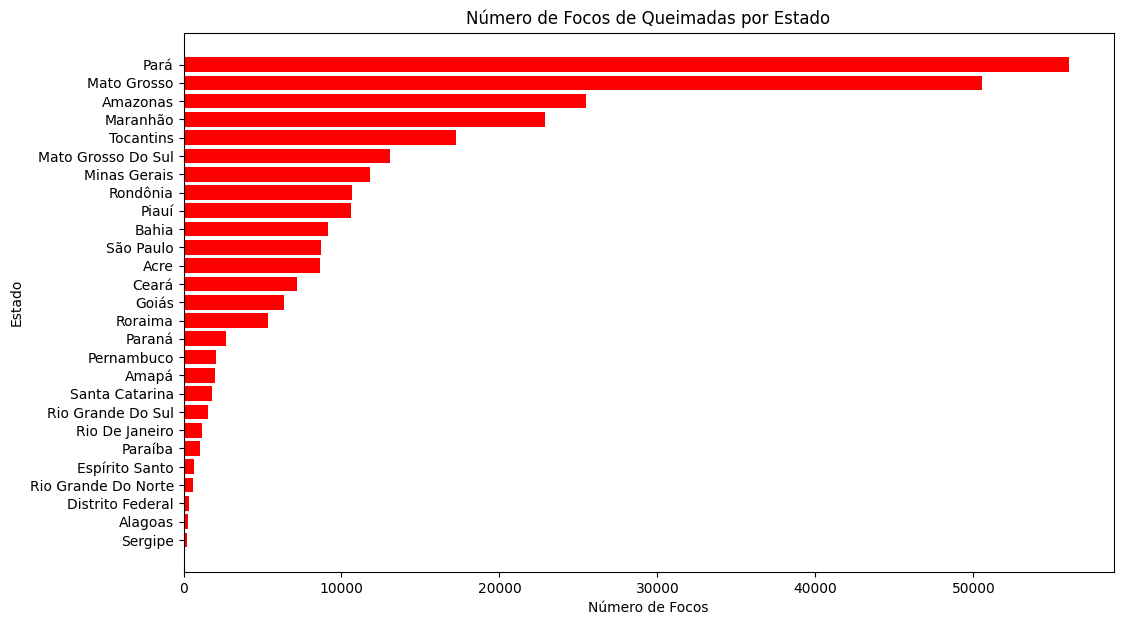

In [40]:
# Cria o gráfico de barras.
plt.figure(figsize=(12, 7))

# Plor dos focos por estado.
plt.barh(df_ordenado['Estado'], df_ordenado['#Focos'], color='red')

# Rotacionar os rótulos do eixo x para o caso de "plt.bar" (barra vertical).
#plt.xticks(rotation=90)

# Adiciona título e rótulos.
plt.ylabel('Estado')
plt.xlabel('Número de Focos')
plt.title('Número de Focos de Queimadas por Estado')

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-01focos_por_estado.png")

# Mostra o gráfico
plt.show()

### Cálculo percentual por estado

In [41]:
# Cálculo percentual na janela de dados selecionada no início do script.

# Calcula o total de focos.
total_geral_focos = df_ordenado['#Focos'].sum()

# Cria uma coluna chamada '%Focos' para calcula a porcentagem de
# focos e arredondar para duas casas decimais.
df_ordenado['%Focos'] = ((df_ordenado['#Focos'] / total_geral_focos) * 100).round(2)

# Visualização do DataFrame com a nova coluna de porcentagem.
df_ordenado

,Estado,#Focos,%Focos
0,Sergipe,190,0.07
1,Alagoas,285,0.10
2,Distrito Federal,349,0.13
3,Rio Grande Do Norte,624,0.22
4,Espírito Santo,662,0.24
5,Paraíba,1074,0.39
6,Rio De Janeiro,1200,0.43
7,Rio Grande Do Sul,1572,0.56
8,Santa Catarina,1801,0.65
9,Amapá,2014,0.72


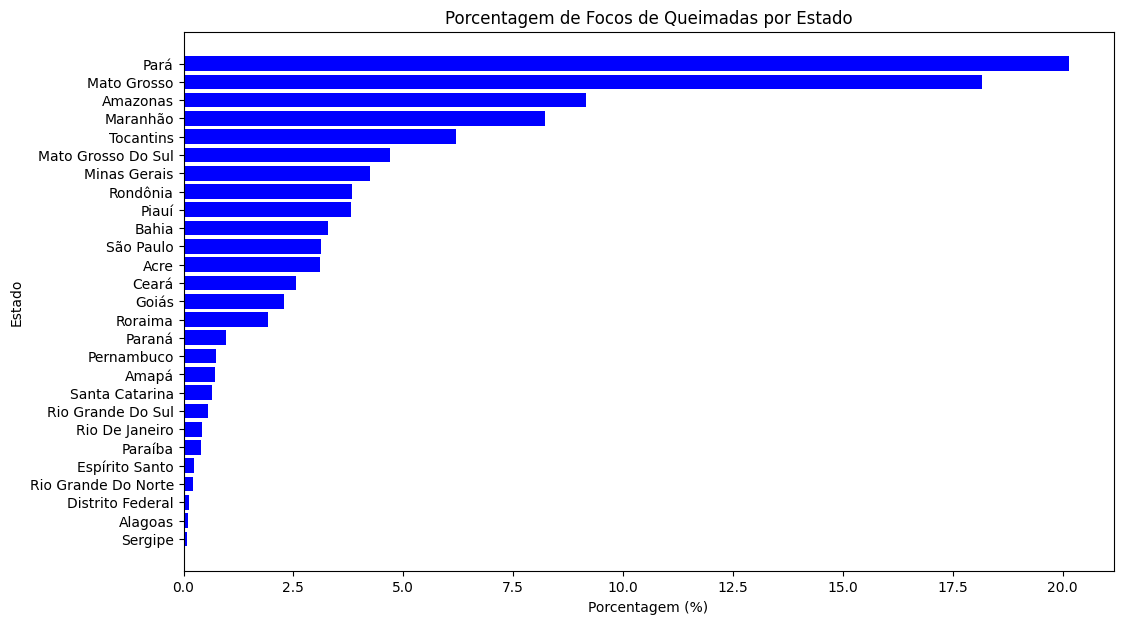

In [42]:
# É o mesmo código da figura anterior.

# Cria o gráfico de barras.
plt.figure(figsize=(12, 7))

# Plot percentual dos focos.
plt.barh(df_ordenado['Estado'], df_ordenado['%Focos'], color='blue')

# Adiciona título e rótulos.
plt.ylabel('Estado')
plt.xlabel('Porcentagem (%)')
plt.title('Porcentagem de Focos de Queimadas por Estado')

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-02focos_por_estado_porcentual.png")

# Mostra o gráfico
plt.show()

### Estatística descritiva dos estados

In [43]:
df_ordenado.describe()

,#Focos,%Focos
count,27.000000,27.000000
mean,10307.370370,3.703704
std,14165.987359,5.089944
min,190.000000,0.070000
25%,1386.000000,0.495000
50%,6362.000000,2.290000
75%,11239.500000,4.040000
max,56070.000000,20.150000


### Mostrar o rank dos estados

In [46]:
# Mostra o rank dos estados com as MAIORES quantidades de focos.
df_ordenado.nlargest(3, "#Focos")

,Estado,#Focos,%Focos
26,Pará,56070,20.15
25,Mato Grosso,50551,18.16
24,Amazonas,25499,9.16


In [47]:
# Mostra o rank dos estados com as MENORES quantidades de focos.
df_ordenado.nsmallest(3, "#Focos")

,Estado,#Focos,%Focos
0,Sergipe,190,0.07
1,Alagoas,285,0.10
2,Distrito Federal,349,0.13


Para realizar as demais análises, será criada uma cópia do DataFrame

In [48]:
# Visualização do DataFrame para o intervalo de datas selecionado.
df_final_copia = df_final.copy()

# Visualização do DataFrame.
df_final_copia

,Lat,Lon,Data,Municipio,Estado,Bioma
0,-14.82900,-40.13300,2003-01-01 16:04:00,NOVA CANAÃ,BAHIA,Mata Atlântica
1,-15.62100,-41.66500,2003-01-01 16:04:00,BERIZAL,MINAS GERAIS,Mata Atlântica
2,-15.27600,-41.51400,2003-01-01 16:04:00,TREMEDAL,BAHIA,Mata Atlântica
3,-10.11100,-36.50500,2003-01-01 16:05:00,IGREJA NOVA,ALAGOAS,Caatinga
4,-11.88600,-37.81500,2003-01-01 16:05:00,ESPLANADA,BAHIA,Mata Atlântica
...,...,...,...,...,...,...
5267632,-8.94582,-71.55865,2026-07-20 20:19:00,JORDÃO,ACRE,Amazônia
5267633,-7.77881,-73.08250,2026-07-20 20:19:00,RODRIGUES ALVES,ACRE,Amazônia
5267634,-9.10678,-71.26778,2026-07-20 20:19:00,FEIJÓ,ACRE,Amazônia
5267635,-8.27815,-70.89651,2026-07-20 20:19:00,TARAUACÁ,ACRE,Amazônia


### Processamento e visualização mensal

Objetivo: Gerar o acumulado mensal dos focos de queimadas para o estado selecionado.

#### Acumulado mensal

In [49]:
# Seleciona o estado de interesse.
nome_estado = "PARÁ"
filtro_interesse = df_final_copia["Estado"] == nome_estado

# Aplica o filtro.
df_estado = df_final_copia[filtro_interesse]

# visualização do DataFrame.
df_estado

,Lat,Lon,Data,Municipio,Estado,Bioma
66,-2.88400,-46.96100,2003-01-01 16:08:00,PARAGOMINAS,PARÁ,Amazônia
67,-2.86500,-46.95800,2003-01-01 16:08:00,PARAGOMINAS,PARÁ,Amazônia
68,-1.80500,-48.19800,2003-01-01 16:08:00,ACARÁ,PARÁ,Amazônia
69,-2.64400,-47.54100,2003-01-01 16:08:00,IPIXUNA DO PARÁ,PARÁ,Amazônia
70,-2.77100,-47.25600,2003-01-01 16:08:00,NOVA ESPERANÇA DO PIRIÁ,PARÁ,Amazônia
...,...,...,...,...,...,...
5267617,-3.18279,-49.52576,2026-07-20 18:43:00,MOJU,PARÁ,Amazônia
5267618,-2.43266,-51.85702,2026-07-20 18:43:00,PORTEL,PARÁ,Amazônia
5267620,-2.79466,-49.53085,2026-07-20 18:43:00,BAIÃO,PARÁ,Amazônia
5267621,-4.75835,-48.83992,2026-07-20 18:43:00,BOM JESUS DO TOCANTINS,PARÁ,Amazônia


In [51]:
# Verificando o tipo do dado.
df_estado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 989971 entries, 66 to 5267622
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Lat        989971 non-null  float64       
 1   Lon        989971 non-null  float64       
 2   Data       989971 non-null  datetime64[ns]
 3   Municipio  989971 non-null  object        
 4   Estado     989971 non-null  object        
 5   Bioma      989971 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 52.9+ MB


In [54]:
# Calcular o acumulado mensal de focos de queimadas para cada ano.
# O "to_period" converte para períodos específicos (meses, anos, estação dentre outros).
# "M" = converte para mês.
# "Y" = converte para ano.
df_acumulado_mensal = df_estado.groupby(by=df_estado["Data"].dt.to_period("M")).Estado.size()

# Visualização mensal dos focos de queimadas.
df_acumulado_mensal

,Estado
Data,
2003-01,1440
2003-02,23
2003-03,28
2003-04,14
2003-05,112
...,...
2026-03,108
2026-04,18
2026-05,233


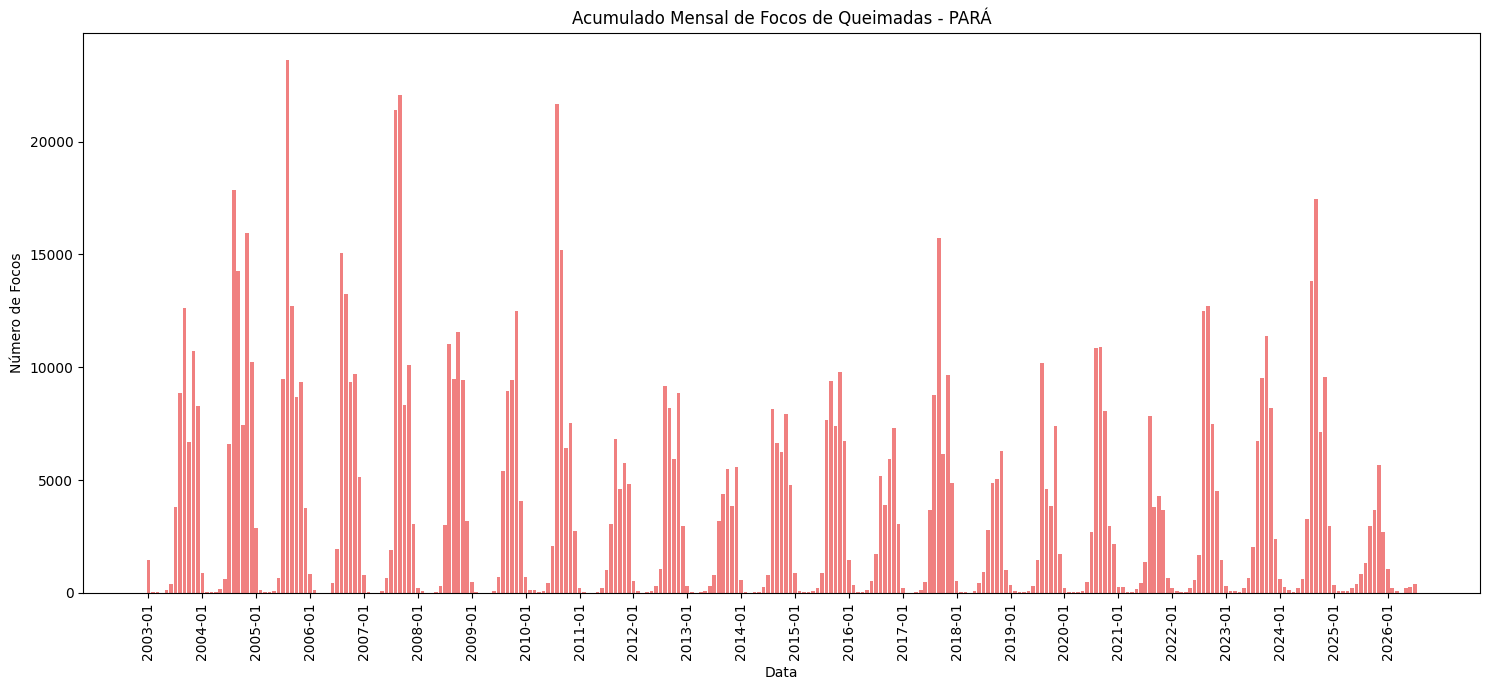

In [56]:
# Formatação do gráfico.
fig = plt.figure(figsize=(15, 7))

# Cria o gráfico de barras vertical.
plt.bar(
    df_acumulado_mensal.index.astype(str),  # Converte o índice de período para string.
    df_acumulado_mensal.values,             # Valores do acumulado mensal.
    color="lightcoral"                      # Cor vermelho claro.
)

# Adiciona título e rótulos aos eixos.
plt.title(f"Acumulado Mensal de Focos de Queimadas - {nome_estado}")
plt.xlabel("Data")
plt.ylabel("Número de Focos")

# Gera posições e rótulos para cada x anos.
x_anos = 1 # Intervalo dos rótulos do eixo x.
tick_positions = []
tick_labels = []
start_year = df_acumulado_mensal.index.year[0] # Pega o primeiro ano do índice
for i, period in enumerate(df_acumulado_mensal.index):
    # Exibe o rótulo apenas para o mês de janeiro dos anos múltiplos de x anos, a partir do ano inicial
    if period.month == 1 and (period.year - start_year) % x_anos == 0:
        tick_positions.append(i)
        tick_labels.append(str(period))

# Plot os xtick em cada posição.
plt.xticks(tick_positions, tick_labels, rotation=90)

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-03acumulado_mensal.png")

# Mostra o gráfico
plt.show()

#### Média mensal

- A partir da média mensal, é possível oberservar o comportamento médio dos focos.
- Para ser considerada uma climatologia, são necessários 30 anos de dados.

In [60]:
# Selecionar o período de interesse para realizar a média mensal considerando 2003 a 2025.
df_media_mensal = df_acumulado_mensal.copy()

# Seleção do período para fazer a média.
# Aconselhável que o ano tenha todos os meses.
df_media_mensal = df_media_mensal.loc["2003-01":"2025-12"]

# Calcula a média mensal do período 2003-2025.
df_media_mensal = df_media_mensal.groupby(df_media_mensal.index.month).mean().round(0).astype(int)

# Renomear "Data" para "Mês" e "Estado" para "#Focos".
df_media_mensal.index.name = "Mês"
df_media_mensal.name = "#Focos"

# Substituir os meses no formato 1, 2, 3, ..., 12 para Jan, Fev, ..., Dez.
meses_map = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
df_media_mensal = df_media_mensal.rename(index=meses_map)

# Visualização da média mensal.
df_media_mensal.reset_index()

,Mês,#Focos
0,Jan,666
1,Fev,97
2,Mar,42
3,Abr,34
4,Mai,111
5,Jun,433
6,Jul,2337
7,Ago,10265
8,Set,10014
9,Out,6983


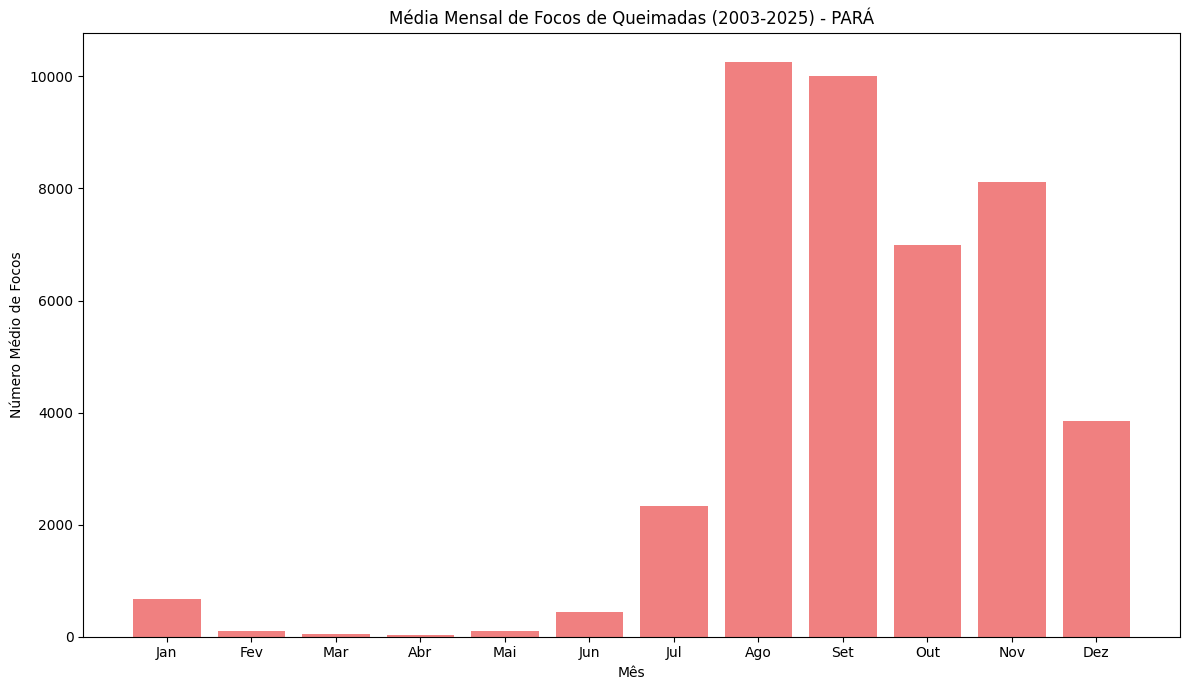

In [67]:
# Formatação do gráfico.
plt.figure(figsize=(12, 7))

# Cria o gráfico de barras vertical.
plt.bar(
    df_media_mensal.index.astype(str),  # Converte o índice de mês para string para o eixo X
    df_media_mensal.values,             # Valores da média mensal.
    color="lightcoral"                  # Cor vermelho claro.
)

# Adiciona título e rótulos aos eixos.
plt.title(f"Média Mensal de Focos de Queimadas (2003-2025) - {nome_estado}")
plt.xlabel("Mês")
plt.ylabel("Número Médio de Focos")

# Rotaciona os rótulos do eixo X se necessário.
plt.xticks(rotation=0)

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-04media_mensal.png")

# Mostra o gráfico
plt.show()

#### Heatmap

Será criada uma tabela pivot (colunas são os meses e as linhas são os anos).

In [68]:
# Cria uma cópia do DataFrame e reinicializa o index.
df_tabela_pivot = df_acumulado_mensal.copy().reset_index()

# Renomeia de "Estado" para "TotalFocos".
df_tabela_pivot = df_tabela_pivot.rename(columns={'Estado': 'TotalFocos'})

# Cria as colunas "Ano" e "Mês" para serem utilizadas na tabela pivot.
df_tabela_pivot['Ano'] = df_tabela_pivot["Data"].dt.year
df_tabela_pivot['Mês'] = df_tabela_pivot["Data"].dt.month

# Cria a tabela pivot e preenche com valor zero o mês com dados faltantes.
df_tabela_pivot = df_tabela_pivot.pivot_table(
    index='Ano',
    columns='Mês',
    values='TotalFocos',
    aggfunc='sum',
    fill_value=0
)

# Mapeamento para substituir os meses no formato 1, 2, 3, ..., 12 para
# Jan, Fev, ..., Dez.
# Quando for 1 altera para Jan, 2 para Fev e assim por diante.
meses_map = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

# Mapeamento dos meses.
df_tabela_pivot = df_tabela_pivot.rename(columns=meses_map)

# Visualização da tabela pivot.
df_tabela_pivot

Mês,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
Ano,,,,,,,,,,,,
2003,1440,23,28,14,112,403,3814,8875,12633,6673,10732,8293
2004,875,36,29,61,193,637,6620,17861,14249,7464,15958,10231
2005,2861,121,32,43,101,656,9464,23635,12728,8689,9368,3779
2006,855,110,18,11,8,423,1955,15064,13225,9346,9684,5141
2007,817,39,17,17,90,671,1885,21386,22055,8346,10114,3054
2008,240,99,11,12,30,328,3020,11035,9463,11568,9456,3187
2009,466,26,11,15,8,91,703,5386,8961,9444,12485,4068
2010,701,147,141,30,97,441,2065,21677,15187,6435,7544,2731
2011,219,25,16,10,21,199,1024,3040,6821,4588,5760,4840


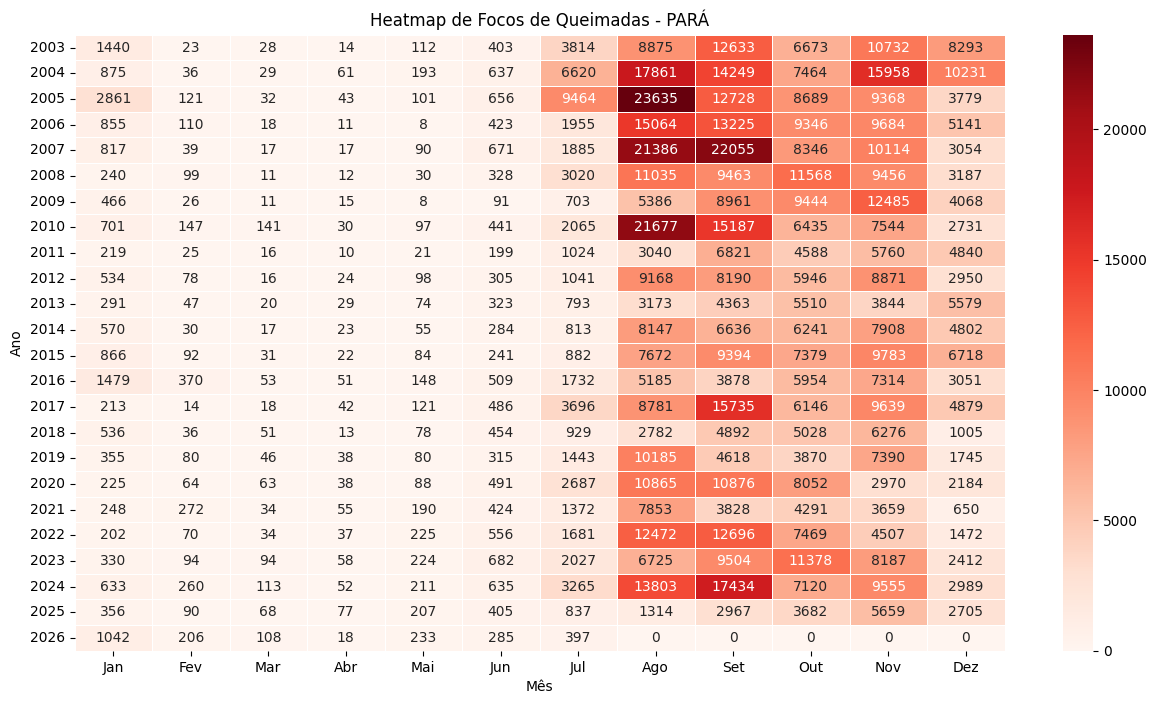

In [69]:
# Criar o heatmap.

plt.figure(figsize=(15, 8))

# Plot do heatamp.
sns.heatmap(
    df_tabela_pivot,
    cmap='Reds',  # Tabela de cores: https://matplotlib.org/stable/users/explain/colors/colormaps.html
    linewidths=0.5,
    annot=True,
    fmt='d'
  )

# Adiciona título e rótulos aos eixos
plt.title(f'Heatmap de Focos de Queimadas - {nome_estado}')
plt.xlabel('Mês')
plt.ylabel('Ano')

# Salva a figura
plt.savefig(f"{diretorio_figuras}/ex03-05heatmap.png")

# Mostra o gráfico
plt.show()

#### Acumulado anual

In [70]:
# Relembrando o DataFrame.
df_estado

,Lat,Lon,Data,Municipio,Estado,Bioma
66,-2.88400,-46.96100,2003-01-01 16:08:00,PARAGOMINAS,PARÁ,Amazônia
67,-2.86500,-46.95800,2003-01-01 16:08:00,PARAGOMINAS,PARÁ,Amazônia
68,-1.80500,-48.19800,2003-01-01 16:08:00,ACARÁ,PARÁ,Amazônia
69,-2.64400,-47.54100,2003-01-01 16:08:00,IPIXUNA DO PARÁ,PARÁ,Amazônia
70,-2.77100,-47.25600,2003-01-01 16:08:00,NOVA ESPERANÇA DO PIRIÁ,PARÁ,Amazônia
...,...,...,...,...,...,...
5267617,-3.18279,-49.52576,2026-07-20 18:43:00,MOJU,PARÁ,Amazônia
5267618,-2.43266,-51.85702,2026-07-20 18:43:00,PORTEL,PARÁ,Amazônia
5267620,-2.79466,-49.53085,2026-07-20 18:43:00,BAIÃO,PARÁ,Amazônia
5267621,-4.75835,-48.83992,2026-07-20 18:43:00,BOM JESUS DO TOCANTINS,PARÁ,Amazônia


In [71]:
# Calcular o acumulado mensal de focos de queimadas para cada ano.
# O "to_period" converte para períodos específicos (meses, anos, estação dentre outros).
# M = converte para mês.
# Y = converte para ano.
df_acumulado_anual = df_estado.groupby(by=df_estado["Data"].dt.to_period("Y")).Estado.size().astype(int)

# Visualização mensal dos focos de queimadas.
df_acumulado_anual

,Estado
Data,
2003,53040
2004,74214
2005,71477
2006,55840
2007,68491
2008,48449
2009,41664
2010,57196
2011,26563


In [72]:
# Resetar o index.
df_acumulado_anual = df_acumulado_anual.reset_index()

# Renomear as colunas.
df_acumulado_anual.columns = ["Ano", "TotalFocos"]

# Visualizar o DataFrame.
df_acumulado_anual

,Ano,TotalFocos
0,2003,53040
1,2004,74214
2,2005,71477
3,2006,55840
4,2007,68491
5,2008,48449
6,2009,41664
7,2010,57196
8,2011,26563
9,2012,37221


In [73]:
# Tipo do dado.
df_acumulado_anual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   Ano         24 non-null     period[Y-DEC]
 1   TotalFocos  24 non-null     int64        
dtypes: int64(1), period[Y-DEC](1)
memory usage: 516.0 bytes


In [74]:
# Cálculo percentual considerando todos os anos.

# Selecionar os anos entre 2003 e 2025.
df_acumulado_anual_2003_2025 = df_acumulado_anual[df_acumulado_anual["Ano"].dt.year.between(2003, 2025)]

df_acumulado_anual_2003_2025

,Ano,TotalFocos
0,2003,53040
1,2004,74214
2,2005,71477
3,2006,55840
4,2007,68491
5,2008,48449
6,2009,41664
7,2010,57196
8,2011,26563
9,2012,37221


In [75]:
# Calculo da média dos focos entre 2003 e 2025.
media_anual = df_acumulado_anual_2003_2025['TotalFocos'].mean().round(0).astype(int)

# Cria uma coluna chamada '%Focos' para calcula a porcentagem de focos.
df_acumulado_anual['%Focos'] = ((df_acumulado_anual['TotalFocos'] / media_anual) * 100).round(0).astype(int)

# Subtrai de 100 para saber se houve aumento ou redução dos focos.
df_acumulado_anual['%Focos'] = df_acumulado_anual['%Focos'] - 100

# Visualização do DataFrame com a nova coluna de porcentagem.
df_acumulado_anual

,Ano,TotalFocos,%Focos
0,2003,53040,24
1,2004,74214,73
2,2005,71477,66
3,2006,55840,30
4,2007,68491,59
5,2008,48449,13
6,2009,41664,-3
7,2010,57196,33
8,2011,26563,-38
9,2012,37221,-13


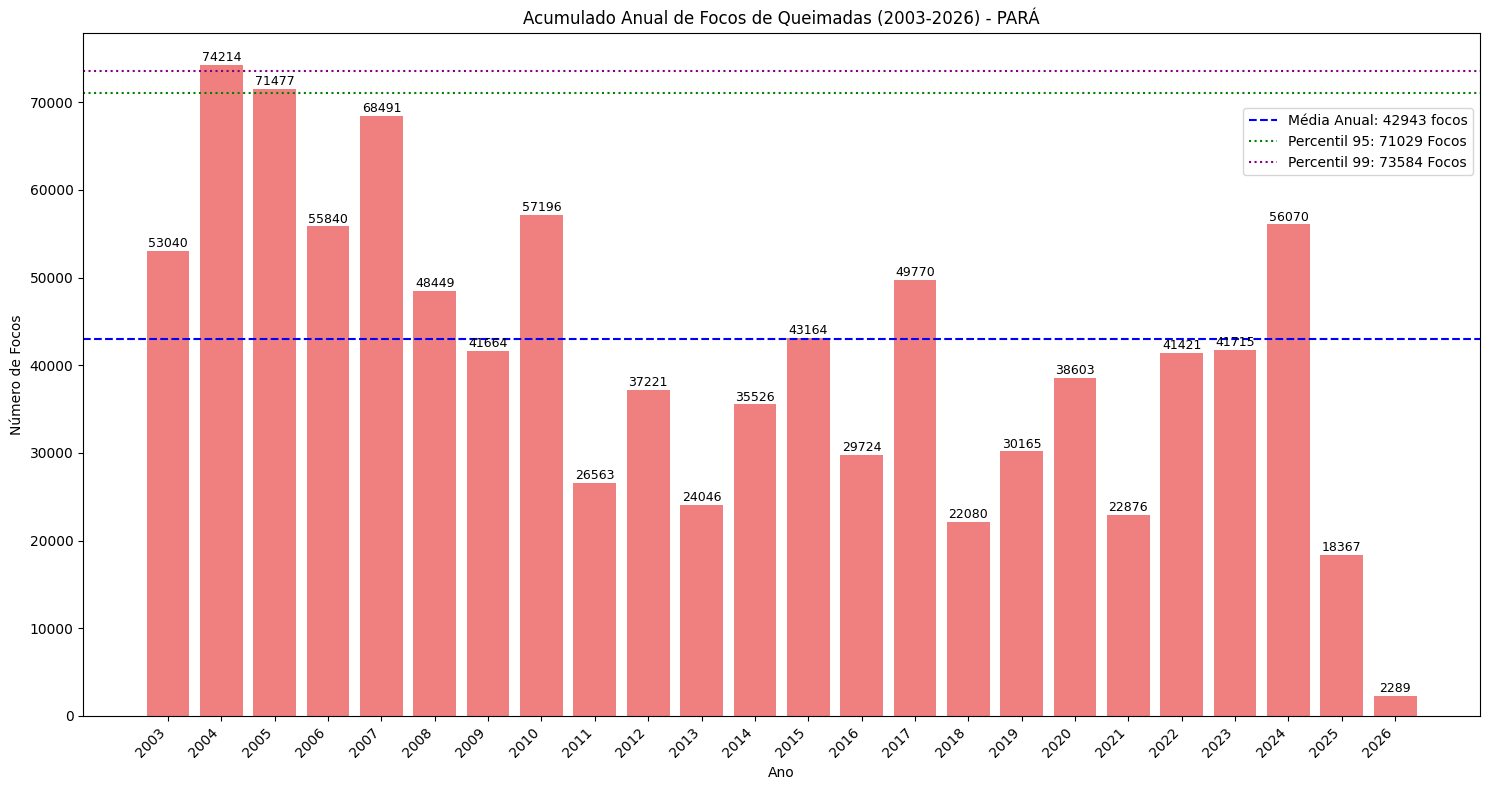

In [85]:
# Formatação do gráfico.
plt.figure(figsize=(15, 8))

# Cria o gráfico de barras vertical com a cor vermelho claro.
bars = plt.bar(
    df_acumulado_anual['Ano'].astype(str), # Converte o ano para string para o rótulo do eixo X
    df_acumulado_anual['TotalFocos'],
    color="lightcoral"
)

# Adiciona os valores de focos em cada coluna do gráfico.
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, round(yval, 0), ha='center', va='bottom', fontsize=9)

# Adiciona uma linha horizontal com o valor da média anual.
plt.axhline(media_anual, color='blue', linestyle='--', label=f'Média Anual: {media_anual:.0f} focos')

# Calcula os percentis 95 e 99 diretamente da coluna 'TotalFocos'.
percentil_95_totalfocos = df_acumulado_anual['TotalFocos'].quantile(0.95).round(0).astype(int)
percentil_99_totalfocos = df_acumulado_anual['TotalFocos'].quantile(0.99).round(0).astype(int)

# Adiciona linhas horizontais para o percentil 95 e 99 (TotalFocos).
plt.axhline(percentil_95_totalfocos, color='green', linestyle=':', label=f'Percentil 95: {percentil_95_totalfocos} Focos')
plt.axhline(percentil_99_totalfocos, color='purple', linestyle=':', label=f'Percentil 99: {percentil_99_totalfocos} Focos')

# Adiciona título e rótulos aos eixos.
plt.title(f'Acumulado Anual de Focos de Queimadas (2003-2026) - {nome_estado}')
plt.xlabel('Ano')
plt.ylabel('Número de Focos')

# Rotaciona os rótulos do eixo X para melhor visualização.
plt.xticks(rotation=45, ha='right')

# Adiciona a legenda para a linha de média e percentis.
# Ajustar o bbox_to_anchor para deslocar a legenda para baixo e para a direita.
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.9))

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-06acumulado_anual.png")

# Mostra o gráfico.
plt.show()

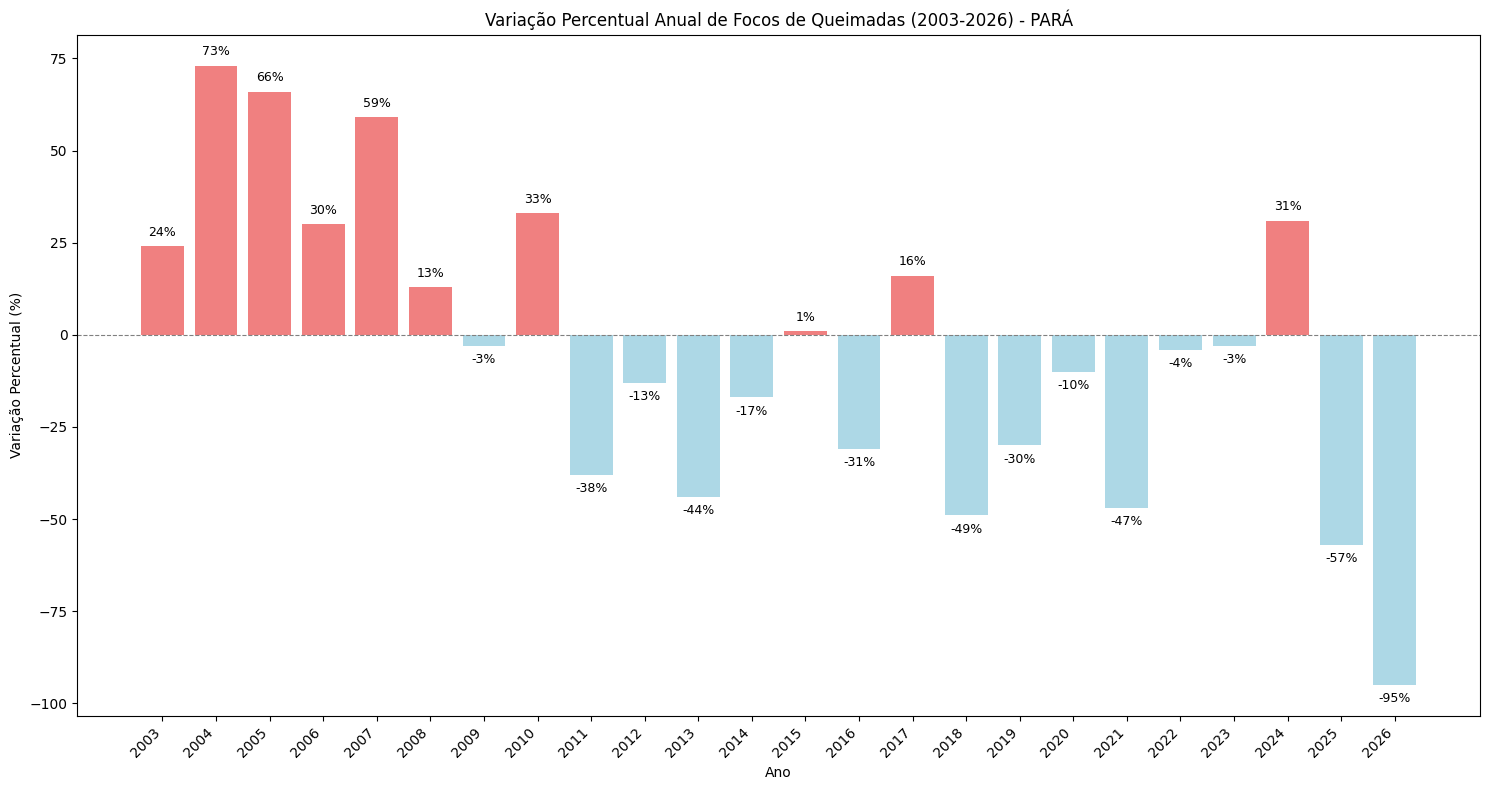

In [86]:
# Formatação do gráfico.
plt.figure(figsize=(15, 8))

# Cria o gráfico de barras condicionalmente.
# Itera sobre cada ano e seu respectivo %Focos.
bars = [] # Lista para armazenar as barras plotadas.
for index, row in df_acumulado_anual.iterrows():
    ano = str(row['Ano'].year) # Converte o ano para string para o rótulo do eixo X
    porcentagem_focos = row['%Focos']

    if porcentagem_focos >= 0:
        # Barras vermelhas para aumento de focos.
        bars.append(plt.bar(ano, porcentagem_focos, color='lightcoral'))
    else:
        # Barras azuis para redução de focos.
        bars.append(plt.bar(ano, porcentagem_focos, color='lightblue'))

# Adiciona os valores de focos em cada coluna do gráfico.
for bar_list in bars:
    # bar_list é uma lista de um único elemento (a barra).
    bar = bar_list[0] if isinstance(bar_list, (list, tuple)) else bar_list
    yval = bar.get_height()
    # Ajusta a posição y para o texto, dependendo se o valor é positivo ou negativo
    va = 'bottom' if yval >= 0 else 'top'
    y_offset = 2 if yval >= 0 else -2
    plt.text(bar.get_x() + bar.get_width()/2, yval + y_offset, f'{yval}%', ha='center', va=va, fontsize=9)

# Adiciona título e rótulos aos eixos.
plt.title(f'Variação Percentual Anual de Focos de Queimadas (2003-2026) - {nome_estado}')
plt.xlabel('Ano')
plt.ylabel('Variação Percentual (%)')

# Adiciona uma linha horizontal no zero para referência.
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Rotaciona os rótulos do eixo X para melhor visualização.
plt.xticks(rotation=45, ha='right')

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-07variacao_percentual.png")

# Mostra o gráfico.
plt.show()

In [78]:
# Visualização do DataFrame.
df_acumulado_anual

,Ano,TotalFocos,%Focos
0,2003,53040,24
1,2004,74214,73
2,2005,71477,66
3,2006,55840,30
4,2007,68491,59
5,2008,48449,13
6,2009,41664,-3
7,2010,57196,33
8,2011,26563,-38
9,2012,37221,-13


In [87]:
# Cria uma cópia do DataFrame.
df_tmp = df_acumulado_anual.copy()

# Remove a coluna "%Focos" para evitar confusão na interpretação do resultado.
df_tmp = df_tmp.drop(columns=['%Focos'])

df_tmp

,Ano,TotalFocos
0,2003,53040
1,2004,74214
2,2005,71477
3,2006,55840
4,2007,68491
5,2008,48449
6,2009,41664
7,2010,57196
8,2011,26563
9,2012,37221


In [88]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   Ano         24 non-null     period[Y-DEC]
 1   TotalFocos  24 non-null     int64        
dtypes: int64(1), period[Y-DEC](1)
memory usage: 516.0 bytes


In [81]:
# Converter a coluna "Ano" para int.
df_tmp['Ano'] = df_tmp['Ano'].dt.year.astype(int).round(2)

df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Ano         24 non-null     int64
 1   TotalFocos  24 non-null     int64
dtypes: int64(2)
memory usage: 516.0 bytes


In [89]:
# O "pct_change()" calcula a variação fracionária entre o elemento atual e um elemento anterior.
# Ou seja, a diferença percentual entre o ano atual e o anterior.
# Exemplo:
# 2024 = 8.712 focos.
# 2025 = 2.376 focos.
# Em porcentagem a mudança de 2025 para 2024 é de -73%.
# diferenca = [Valor atual - Valor anterior]/Valor anterior
# diferenca = [2.376 - 8.712]/8.712 = -0.73 x 100% = -73%.
df_tmp["VariacaoPct"] = (df_tmp["TotalFocos"].pct_change().mul(100).round(0).fillna(0))

df_tmp

,Ano,TotalFocos,VariacaoPct
0,2003,53040,0.0
1,2004,74214,40.0
2,2005,71477,-4.0
3,2006,55840,-22.0
4,2007,68491,23.0
5,2008,48449,-29.0
6,2009,41664,-14.0
7,2010,57196,37.0
8,2011,26563,-54.0
9,2012,37221,40.0


In [93]:
# Monta o rótulo dos anos, exemplo: 2004-2003, 2005-2004, ..., 2026-2025 que ficarão
# no eixo x. Isso tem a ver com o cálculo feito.

# Cria a coluna "Periodo" com os valores acima.
df_tmp["Periodo"] = (df_tmp["Ano"].astype(str) + "-" + (df_tmp["Ano"] - 1).astype(str))

# Remove a primeira linha porque ela tem valor zero..
df_tmp = df_tmp.iloc[1:]

df_tmp

/tmp/ipykernel_1147/1086430065.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp["Periodo"] = (df_tmp["Ano"].astype(str) + "-" + (df_tmp["Ano"] - 1).astype(str))


,Ano,TotalFocos,VariacaoPct,Periodo
2,2005,71477,-4.0,2005-2004
3,2006,55840,-22.0,2006-2005
4,2007,68491,23.0,2007-2006
5,2008,48449,-29.0,2008-2007
6,2009,41664,-14.0,2009-2008
7,2010,57196,37.0,2010-2009
8,2011,26563,-54.0,2011-2010
9,2012,37221,40.0,2012-2011
10,2013,24046,-35.0,2013-2012
11,2014,35526,48.0,2014-2013


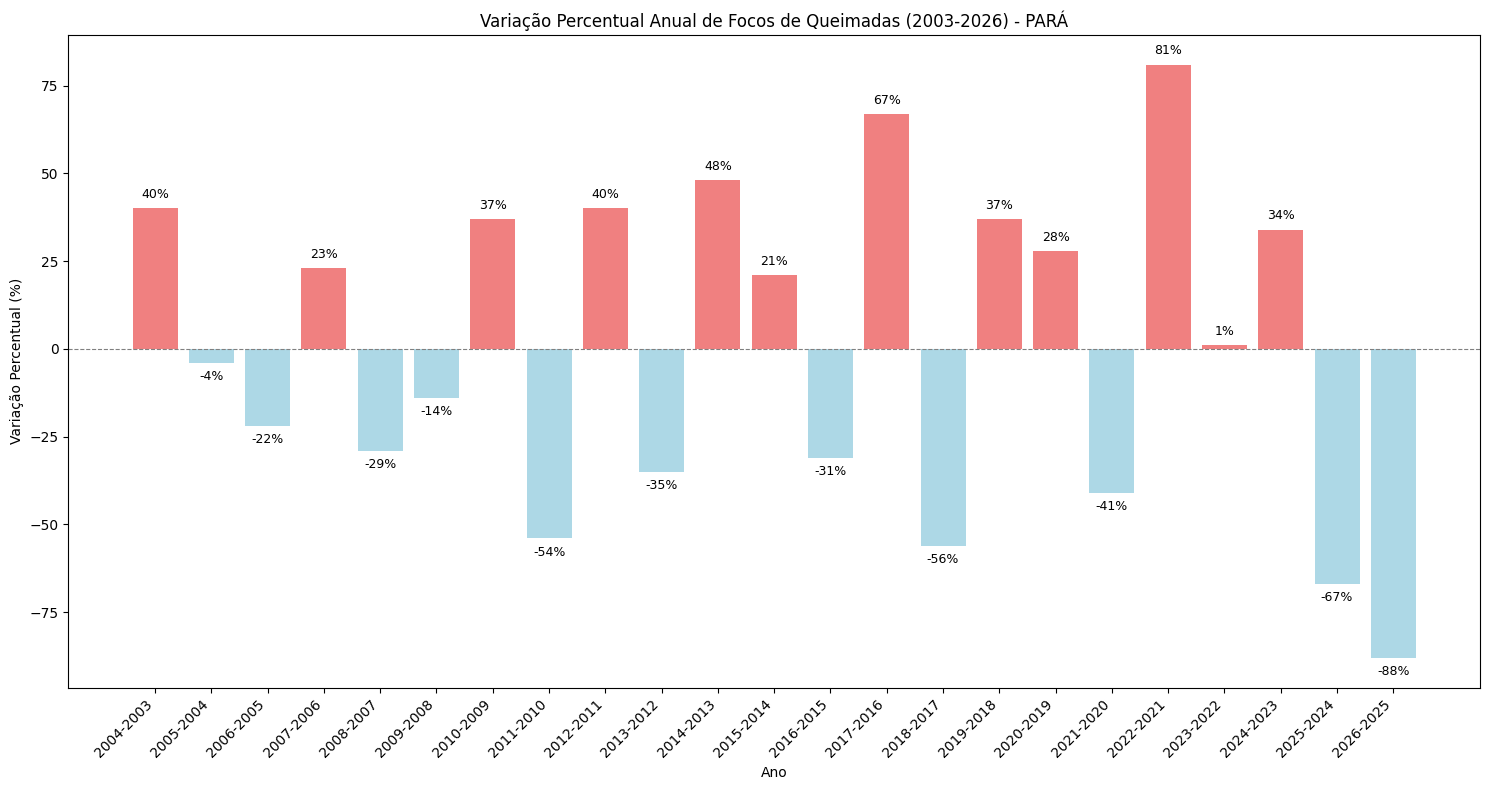

In [92]:
# Formatação do gráfico.
plt.figure(figsize=(15, 8))

# Define as cores das barras.
cores = np.where(df_tmp["VariacaoPct"] >= 0, "lightcoral", "lightblue")

# Cria todas as barras de uma vez.
bars = plt.bar(
    df_tmp["Periodo"].astype(str),
    df_tmp["VariacaoPct"],
    color=cores
)

# Adiciona os valores sobre as barras.
for bar in bars:
    yval = bar.get_height()

    va = "bottom" if yval >= 0 else "top"
    y_offset = 2 if yval >= 0 else -2

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + y_offset,
        f"{int(yval)}%",
        ha="center",
        va=va,
        fontsize=9
    )

# Adiciona título e rótulos aos eixos.
plt.title(f"Variação Percentual Anual de Focos de Queimadas (2003-2026) - {nome_estado}")
plt.xlabel("Ano")
plt.ylabel("Variação Percentual (%)")

# Linha horizontal em y = 0.
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

# Mostra todos os anos no eixo X.
plt.xticks(rotation=45, ha="right")

# Ajusta layout.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-08diferenca_percentual.png", dpi=300)

# Mostra o gráfico.
plt.show()